# **Week 2 : Feature Engineering and Baseline ML**

In [ ]:
pip install haversine

In [ ]:
import pandas as pd
import numpy as np

from math import radians, sin, cos, sqrt, atan2

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error,mean_absolute_percentage_error,r2_score)

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("week1_AB_NYC_2019.zip")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
encoder = LabelEncoder()

df["room_type"] = encoder.fit_transform(df["room_type"])

df["neighbourhood_group"] = encoder.fit_transform(
    df["neighbourhood_group"]
)

df["neighbourhood"] = encoder.fit_transform(
    df["neighbourhood"]
)

In [ ]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = radians(lat1)
    lon1 = radians(lon1)

    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + \
        cos(lat1) * cos(lat2) * sin(dlon/2)**2

    c = 2 * atan2(
        sqrt(a),
        sqrt(1-a)
    )

    return R * c

In [ ]:
CITY_LAT = 40.7580
CITY_LON = -73.9855

df["distance_to_center"] = df.apply(lambda row:haversine(row["latitude"],row["longitude"],CITY_LAT,CITY_LON),axis=1)

print(df["distance_to_center"].head())

0    12.337898
1     0.508366
2     6.757240
3     8.387034
4     5.701496
Name: distance_to_center, dtype: float64


In [ ]:
df["availability_ratio"] = (
    df["availability_365"] / 365
)

In [ ]:
df["review_density"] = (df["number_of_reviews"]/(df["minimum_nights"] + 1))

In [ ]:
df["price_per_night"] = (df["price"]/(df["minimum_nights"] + 1))

In [ ]:
print(df[[
    "distance_to_center",
    "availability_ratio",
    "review_density",
    "price_per_night"
]].head())

   distance_to_center  availability_ratio  review_density  price_per_night
0           12.337898            1.000000        4.500000        74.500000
1            0.508366            0.972603       22.500000       112.500000
2            6.757240            1.000000        0.000000        37.500000
3            8.387034            0.531507      135.000000        44.500000
4            5.701496            0.000000        0.818182         7.272727


In [ ]:
features = ["latitude","longitude","room_type","neighbourhood_group", "minimum_nights","number_of_reviews","reviews_per_month","availability_365","distance_to_center","availability_ratio","review_density"]

X = df[features]

y = df["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [ ]:
model = XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=6,

    random_state=42

)

model.fit(

    X_train,

    y_train

)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
prediction = model.predict(X_test)

In [ ]:
rmse = np.sqrt(

    mean_squared_error(

        y_test,

        prediction

    )

)

mape = mean_absolute_percentage_error(

    y_test,

    prediction

)

r2 = r2_score(

    y_test,

    prediction

)

print("RMSE :", rmse)
print("MAPE :", mape)
print("R² :", r2)

RMSE : 44.72966624056329
MAPE : 143672611962880.0
R² : 0.5757426023483276


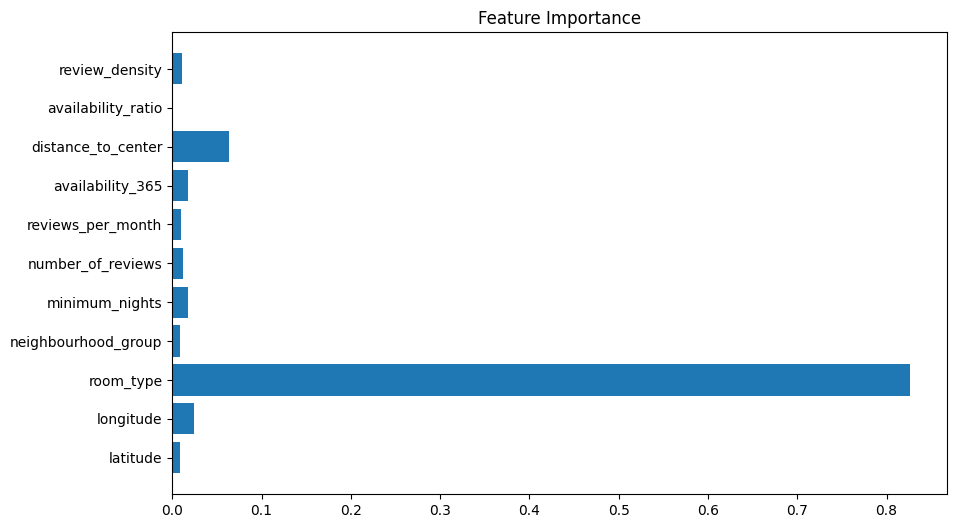

In [ ]:
importance = model.feature_importances_

plt.figure(figsize=(10,6))

plt.barh(

    features,

    importance

)

plt.title("Feature Importance")

plt.show()

In [ ]:
df.to_csv("week2_AB_NYC_2019.zip",index=False)

print("Week 2 Completed Successfully")

Week 2 Completed Successfully
